In [25]:
import duckdb
import pandas as pd

con = duckdb.connect('doac_analysis.duckdb')

con.sql("""
    CREATE OR REPLACE TABLE open_payments_raw AS
    SELECT * FROM read_csv_auto('C:/Users/19735/Desktop/doac-case-study/OP_DTL_GNRL_PGYR2023_P06302026_06032026.csv')
""")

con.sql("""
    CREATE OR REPLACE TABLE partd_prescriber_raw AS
    SELECT * FROM read_csv_auto('C:/Users/19735/Desktop/doac-case-study/Medicare_Part_D_Prescribers_by_Provider_and_Drug_2024.csv')
""")

print("Loaded successfully")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded successfully


In [26]:
print(con.sql("DESCRIBE open_payments_raw").df()['column_name'].tolist())

['Change_Type', 'Covered_Recipient_Type', 'Teaching_Hospital_CCN', 'Teaching_Hospital_ID', 'Teaching_Hospital_Name', 'Covered_Recipient_Profile_ID', 'Covered_Recipient_NPI', 'Covered_Recipient_First_Name', 'Covered_Recipient_Middle_Name', 'Covered_Recipient_Last_Name', 'Covered_Recipient_Name_Suffix', 'Recipient_Primary_Business_Street_Address_Line1', 'Recipient_Primary_Business_Street_Address_Line2', 'Recipient_City', 'Recipient_State', 'Recipient_Zip_Code', 'Recipient_Country', 'Recipient_Province', 'Recipient_Postal_Code', 'Covered_Recipient_Primary_Type_1', 'Covered_Recipient_Primary_Type_2', 'Covered_Recipient_Primary_Type_3', 'Covered_Recipient_Primary_Type_4', 'Covered_Recipient_Primary_Type_5', 'Covered_Recipient_Primary_Type_6', 'Covered_Recipient_Specialty_1', 'Covered_Recipient_Specialty_2', 'Covered_Recipient_Specialty_3', 'Covered_Recipient_Specialty_4', 'Covered_Recipient_Specialty_5', 'Covered_Recipient_Specialty_6', 'Covered_Recipient_License_State_code1', 'Covered_Reci

In [27]:
print(con.sql("DESCRIBE partd_prescriber_raw").df()['column_name'].tolist())

['Prscrbr_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_State_FIPS', 'Prscrbr_Type', 'Prscrbr_Type_Src', 'Brnd_Name', 'Gnrc_Name', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply', 'Tot_Drug_Cst', 'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms', 'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply', 'GE65_Bene_Sprsn_Flag', 'GE65_Tot_Benes']


In [28]:
con.sql("SELECT DISTINCT Covered_Recipient_Type FROM open_payments_raw").show()

┌──────────────────────────────────────────────┐
│            Covered_Recipient_Type            │
│                   varchar                    │
├──────────────────────────────────────────────┤
│ Covered Recipient Non-Physician Practitioner │
│ Covered Recipient Teaching Hospital          │
│ Covered Recipient Physician                  │
└──────────────────────────────────────────────┘



In [29]:
con.sql("""
    SELECT COUNT(*) AS matching_rows
    FROM open_payments_raw
    WHERE Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 LIKE '%Eliquis%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2 LIKE '%Eliquis%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3 LIKE '%Eliquis%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4 LIKE '%Eliquis%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5 LIKE '%Eliquis%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 LIKE '%Xarelto%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2 LIKE '%Xarelto%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3 LIKE '%Xarelto%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4 LIKE '%Xarelto%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5 LIKE '%Xarelto%'
""").show()

┌───────────────┐
│ matching_rows │
│     int64     │
├───────────────┤
│             0 │
└───────────────┘



In [30]:
con.sql("SELECT DISTINCT Nature_of_Payment_or_Transfer_of_Value FROM open_payments_raw LIMIT 20").show()

┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                                       Nature_of_Payment_or_Transfer_of_Value                                                       │
│                                                                      varchar                                                                       │
├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Gift                                                                                                                                               │
│ Charitable Contribution                                                                                                                            │
│ Long term medical supply or device loan                                                     

In [31]:
con.sql("SELECT COUNT(*) AS total_rows FROM open_payments_raw").show()

┌────────────┐
│ total_rows │
│   int64    │
├────────────┤
│   14734121 │
└────────────┘



In [32]:
con.sql("""
    SELECT COUNT(*) AS matching_rows
    FROM open_payments_raw
    WHERE Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 ILIKE '%Eliquis%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2 ILIKE '%Eliquis%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3 ILIKE '%Eliquis%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4 ILIKE '%Eliquis%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5 ILIKE '%Eliquis%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 ILIKE '%Xarelto%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2 ILIKE '%Xarelto%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3 ILIKE '%Xarelto%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4 ILIKE '%Xarelto%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5 ILIKE '%Xarelto%'
""").show()

┌───────────────┐
│ matching_rows │
│     int64     │
├───────────────┤
│        266120 │
└───────────────┘



In [33]:
con.sql("""
    SELECT DISTINCT Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1
    FROM open_payments_raw
    WHERE Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 IS NOT NULL
    LIMIT 20
""").show()

┌──────────────────────────────────────────────────────────┐
│ Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 │
│                         varchar                          │
├──────────────────────────────────────────────────────────┤
│ Mariner Deformity                                        │
│ Pillar SA                                                │
│ NewBridge                                                │
│ AMELUZ                                                   │
│ ALINITY M                                                │
│ AGILIS HISPRO                                            │
│ PERCEPTA QUAD CRT-P MRI SURESCAN                         │
│ PIPELINE                                                 │
│ OptiCross                                                │
│ Rezum Generator                                          │
│ ProTaper Ultimate Treatment Covience Kit                 │
│ Vortex Blue Conform Fit                                  │
│ EDWARDS SAPIEN 3 TRANS

In [40]:
con.sql("""
    CREATE OR REPLACE TABLE open_payments_doac_clean AS
    SELECT
        CAST(Covered_Recipient_NPI AS VARCHAR) AS npi,
        Covered_Recipient_Specialty_1 AS raw_specialty,
        Recipient_State AS state,
        Nature_of_Payment_or_Transfer_of_Value AS payment_nature,
        Total_Amount_of_Payment_USDollars AS payment_amount,
        Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name AS manufacturer_raw,
        CASE
            WHEN Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Pfizer%' THEN 'Pfizer'
            WHEN Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Janssen%' THEN 'Janssen (J&J)'
            WHEN Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Bayer%' THEN 'Bayer'
            WHEN Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Bristol%' THEN 'Bristol Myers Squibb'
        END AS manufacturer,
        CASE
            WHEN Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 ILIKE '%Eliquis%'
                OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2 ILIKE '%Eliquis%'
                OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3 ILIKE '%Eliquis%'
                OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4 ILIKE '%Eliquis%'
                OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5 ILIKE '%Eliquis%'
                THEN 'Eliquis'
            WHEN Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 ILIKE '%Xarelto%'
                OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2 ILIKE '%Xarelto%'
                OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3 ILIKE '%Xarelto%'
                OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4 ILIKE '%Xarelto%'
                OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5 ILIKE '%Xarelto%'
                THEN 'Xarelto'
        END AS brand
    FROM open_payments_raw
    WHERE Covered_Recipient_Type = 'Covered Recipient Physician'
        AND Covered_Recipient_NPI IS NOT NULL
        AND (
            Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 ILIKE '%Eliquis%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2 ILIKE '%Eliquis%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3 ILIKE '%Eliquis%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4 ILIKE '%Eliquis%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5 ILIKE '%Eliquis%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 ILIKE '%Xarelto%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2 ILIKE '%Xarelto%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3 ILIKE '%Xarelto%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4 ILIKE '%Xarelto%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5 ILIKE '%Xarelto%'
        )
""")

print(con.sql("SELECT COUNT(*) FROM open_payments_doac_clean").df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   count_star()
0        181452


In [41]:
con.sql("SELECT brand, COUNT(*) FROM open_payments_doac_clean GROUP BY brand").show()
con.sql("SELECT DISTINCT raw_specialty FROM open_payments_doac_clean LIMIT 20").show()

┌─────────┬──────────────┐
│  brand  │ count_star() │
│ varchar │    int64     │
├─────────┼──────────────┤
│ Eliquis │       103153 │
│ Xarelto │        78299 │
└─────────┴──────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                                raw_specialty                                                │
│                                                   varchar                                                   │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Allopathic & Osteopathic Physicians|Emergency Medicine                                                      │
│ Allopathic & Osteopathic Physicians|Pathology|Anatomic Pathology & Clinical Pathology                       │
│ Allopathic & Osteopathic Physicians|Internal Medicine|Nephrology                                            │
│ Allopathic & Osteopathic

In [42]:
con.sql("""
    SELECT COUNT(*) AS rivaroxaban_matches
    FROM open_payments_raw
    WHERE Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 ILIKE '%rivaroxaban%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2 ILIKE '%rivaroxaban%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3 ILIKE '%rivaroxaban%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4 ILIKE '%rivaroxaban%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5 ILIKE '%rivaroxaban%'
""").show()

┌─────────────────────┐
│ rivaroxaban_matches │
│        int64        │
├─────────────────────┤
│                   0 │
└─────────────────────┘



In [43]:
con.sql("""
    SELECT DISTINCT Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name
    FROM open_payments_raw
    WHERE Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Janssen%'
       OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Bayer%'
       OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Bristol%'
       OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Pfizer%'
    LIMIT 20
""").show()

┌───────────────────────────────────────────────────────────────┐
│ Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name │
│                            varchar                            │
├───────────────────────────────────────────────────────────────┤
│ PFIZER ZONA FRANCA, S.A.                                      │
│ PFIZER PHARMACEUTICALS KOREA LIMITED                          │
│ Bayer Healthcare Pharmaceuticals Inc.                         │
│ Janssen Scientific Affairs, LLC                               │
│ Pfizer Inc.                                                   │
│ Janssen Global Services, LLC                                  │
│ Bristol Myers Squibb Company                                  │
│ Janssen Products, LP                                          │
│ Janssen Research & Development, LLC                           │
│ PFIZER INC.                                                   │
│ PFIZER LIMITED                                                │
│ PFIZER P

In [44]:
con.sql("""
    SELECT Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name, COUNT(*) as row_count
    FROM open_payments_raw
    WHERE Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Janssen%'
       OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Bayer%'
       OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Bristol%'
       OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Pfizer%'
    GROUP BY 1
    ORDER BY 2 DESC
""").show()

┌───────────────────────────────────────────────────────────────┬───────────┐
│ Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name │ row_count │
│                            varchar                            │   int64   │
├───────────────────────────────────────────────────────────────┼───────────┤
│ PFIZER INC.                                                   │    515135 │
│ Janssen Biotech, Inc.                                         │    257833 │
│ Janssen Pharmaceuticals, Inc                                  │    209118 │
│ Bayer Healthcare Pharmaceuticals Inc.                         │    186426 │
│ Janssen Scientific Affairs, LLC                               │      7880 │
│ Janssen Research & Development, LLC                           │      2529 │
│ Janssen Products, LP                                          │      1047 │
│ Janssen Global Services, LLC                                  │       714 │
│ Bayer Puerto Rico Inc.                                        

In [45]:
con.sql("""
    SELECT DISTINCT Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1
    FROM open_payments_raw
    WHERE (Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Janssen%'
        OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Bayer%')
      AND Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 IS NOT NULL
    LIMIT 30
""").show()

┌──────────────────────────────────────────────────────────┐
│ Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 │
│                         varchar                          │
├──────────────────────────────────────────────────────────┤
│ Essure                                                   │
│ STELARA                                                  │
│ PIPELINE                                                 │
│ Mirena                                                   │
│ ZYTIGA                                                   │
│ Aliqopa                                                  │
│ Betaseron                                                │
│ Skyla                                                    │
│ Ponvory                                                  │
│ AKEEGA                                                   │
│   ·                                                      │
│   ·                                                      │
│   ·                   

In [46]:
con.sql("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1) AS non_null_drug_field_1
    FROM open_payments_raw
    WHERE Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Janssen%'
       OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Bayer%'
""").show()

┌────────────┬───────────────────────┐
│ total_rows │ non_null_drug_field_1 │
│   int64    │         int64         │
├────────────┼───────────────────────┤
│     666598 │                654228 │
└────────────┴───────────────────────┘



In [47]:
con.sql("""
    SELECT Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1, COUNT(*) AS row_count
    FROM open_payments_raw
    WHERE (Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Janssen%'
        OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Bayer%')
      AND Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 IS NOT NULL
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 30
""").show()

┌──────────────────────────────────────────────────────────┬───────────┐
│ Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 │ row_count │
│                         varchar                          │   int64   │
├──────────────────────────────────────────────────────────┼───────────┤
│ Kerendia                                                 │    143321 │
│ XARELTO                                                  │    118350 │
│ TREMFYA                                                  │    114910 │
│ SPRAVATO                                                 │     45170 │
│ STELARA                                                  │     44951 │
│ INVEGA SUSTENNA                                          │     41571 │
│ REMICADE                                                 │     33841 │
│ ERLEADA                                                  │     24908 │
│ Nubeqa                                                   │     15242 │
│ DARZALEX                                         

In [48]:
con.sql("""
    SELECT Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1, COUNT(*) AS row_count
    FROM open_payments_raw
    WHERE Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 ILIKE '%arelt%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2 ILIKE '%arelt%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3 ILIKE '%arelt%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4 ILIKE '%arelt%'
       OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5 ILIKE '%arelt%'
    GROUP BY 1
""").show()

┌──────────────────────────────────────────────────────────┬───────────┐
│ Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 │ row_count │
│                         varchar                          │   int64   │
├──────────────────────────────────────────────────────────┼───────────┤
│ INVOKANA                                                 │       273 │
│ STELARA                                                  │         3 │
│ IMBRUVICA                                                │         1 │
│ XARELTO                                                  │    118363 │
└──────────────────────────────────────────────────────────┴───────────┘



In [49]:
con.sql("""
    CREATE OR REPLACE TABLE open_payments_doac_agg AS
    SELECT
        npi,
        brand,
        ANY_VALUE(raw_specialty) AS raw_specialty,
        ANY_VALUE(state) AS state,
        COUNT(*) AS num_payments,
        SUM(payment_amount) AS total_payment_amount,
        MODE(payment_nature) AS top_payment_nature
    FROM open_payments_doac_clean
    GROUP BY npi, brand
""")

con.sql("SELECT brand, COUNT(*) AS num_prescribers FROM open_payments_doac_agg GROUP BY brand").show()

┌─────────┬─────────────────┐
│  brand  │ num_prescribers │
│ varchar │      int64      │
├─────────┼─────────────────┤
│ Xarelto │           28479 │
│ Eliquis │           34473 │
└─────────┴─────────────────┘



In [50]:
con.sql("""
    SELECT DISTINCT Brnd_Name
    FROM partd_prescriber_raw
    WHERE Brnd_Name ILIKE '%eliquis%' OR Brnd_Name ILIKE '%xarelto%'
""").show()

┌───────────┐
│ Brnd_Name │
│  varchar  │
├───────────┤
│ Xarelto   │
│ Eliquis   │
└───────────┘



In [51]:
con.sql("""
    SELECT Brnd_Name, COUNT(*) AS row_count
    FROM partd_prescriber_raw
    WHERE Brnd_Name ILIKE '%eliquis%' OR Brnd_Name ILIKE '%xarelto%'
    GROUP BY 1
""").show()

┌───────────┬───────────┐
│ Brnd_Name │ row_count │
│  varchar  │   int64   │
├───────────┼───────────┤
│ Eliquis   │    264286 │
│ Xarelto   │    134291 │
└───────────┴───────────┘



In [52]:
con.sql("""
    CREATE OR REPLACE TABLE partd_doac_clean AS
    SELECT
        CAST(Prscrbr_NPI AS VARCHAR) AS npi,
        Prscrbr_Type AS raw_specialty,
        Prscrbr_State_Abrvtn AS state,
        Brnd_Name AS brand,
        Tot_Clms AS total_claims,
        Tot_Day_Suply AS total_day_supply,
        Tot_Drug_Cst AS total_drug_cost
    FROM partd_prescriber_raw
    WHERE Brnd_Name ILIKE '%eliquis%' OR Brnd_Name ILIKE '%xarelto%'
""")

con.sql("SELECT brand, COUNT(*) FROM partd_doac_clean GROUP BY brand").show()

┌─────────┬──────────────┐
│  brand  │ count_star() │
│ varchar │    int64     │
├─────────┼──────────────┤
│ Eliquis │       264286 │
│ Xarelto │       134291 │
└─────────┴──────────────┘



In [53]:
con.sql("""
    CREATE OR REPLACE TABLE partd_doac_bucketed AS
    SELECT
        *,
        CASE
            WHEN raw_specialty ILIKE '%cardio%' THEN 'Cardiology'
            WHEN raw_specialty ILIKE '%internal medicine%' THEN 'Internal Medicine'
            WHEN raw_specialty ILIKE '%family%' THEN 'Family Medicine'
            WHEN raw_specialty ILIKE '%nurse practitioner%' OR raw_specialty ILIKE '%physician assistant%' THEN 'NP/PA'
            ELSE 'Other'
        END AS specialty_bucket
    FROM partd_doac_clean
""")

con.sql("SELECT specialty_bucket, COUNT(*) FROM partd_doac_bucketed GROUP BY 1 ORDER BY 2 DESC").show()

┌───────────────────┬──────────────┐
│ specialty_bucket  │ count_star() │
│      varchar      │    int64     │
├───────────────────┼──────────────┤
│ NP/PA             │       122201 │
│ Family Medicine   │        94440 │
│ Internal Medicine │        87630 │
│ Other             │        54037 │
│ Cardiology        │        40269 │
└───────────────────┴──────────────┘



In [54]:
con.sql("""
    SELECT raw_specialty, COUNT(*) AS row_count
    FROM partd_doac_bucketed
    WHERE specialty_bucket = 'Other'
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 15
""").show()

┌────────────────────────────────────────────────────────────────┬───────────┐
│                         raw_specialty                          │ row_count │
│                            varchar                             │   int64   │
├────────────────────────────────────────────────────────────────┼───────────┤
│ Hematology-Oncology                                            │     10077 │
│ Hospitalist                                                    │      6812 │
│ General Practice                                               │      5208 │
│ Clinical Cardiac Electrophysiology                             │      4561 │
│ Pulmonary Disease                                              │      2985 │
│ Medical Oncology                                               │      2920 │
│ Vascular Surgery                                               │      2759 │
│ Student in an Organized Health Care Education/Training Program │      2617 │
│ Geriatric Medicine                                

In [55]:
con.sql("""
    CREATE OR REPLACE TABLE partd_doac_bucketed AS
    SELECT
        *,
        CASE
            WHEN raw_specialty ILIKE '%cardio%' OR raw_specialty ILIKE '%cardiac%' THEN 'Cardiology'
            WHEN raw_specialty ILIKE '%internal medicine%' THEN 'Internal Medicine'
            WHEN raw_specialty ILIKE '%family%' OR raw_specialty ILIKE '%general practice%' THEN 'Family Medicine'
            WHEN raw_specialty ILIKE '%nurse practitioner%' OR raw_specialty ILIKE '%physician assistant%' THEN 'NP/PA'
            WHEN raw_specialty ILIKE '%hospitalist%' THEN 'Hospitalist'
            ELSE 'Other'
        END AS specialty_bucket
    FROM partd_doac_clean
""")

con.sql("SELECT specialty_bucket, COUNT(*) FROM partd_doac_bucketed GROUP BY 1 ORDER BY 2 DESC").show()

┌───────────────────┬──────────────┐
│ specialty_bucket  │ count_star() │
│      varchar      │    int64     │
├───────────────────┼──────────────┤
│ NP/PA             │       122201 │
│ Family Medicine   │        99648 │
│ Internal Medicine │        87630 │
│ Cardiology        │        44961 │
│ Other             │        37325 │
│ Hospitalist       │         6812 │
└───────────────────┴──────────────┘



In [56]:
con.sql("""
    CREATE OR REPLACE TABLE doac_master_analysis AS
    SELECT
        p.npi,
        p.brand,
        p.specialty_bucket,
        p.state,
        p.total_claims,
        p.total_day_supply,
        p.total_drug_cost,
        COALESCE(op.total_payment_amount, 0) AS total_payment_amount,
        COALESCE(op.num_payments, 0) AS num_payments,
        op.top_payment_nature,
        CASE WHEN op.npi IS NULL THEN 'Unpaid' ELSE 'Paid' END AS paid_status,
        CASE
            WHEN op.total_payment_amount IS NULL THEN 'No Payment'
            WHEN op.total_payment_amount < 100 THEN 'Low ($0-100)'
            WHEN op.total_payment_amount < 1000 THEN 'Medium ($100-1000)'
            ELSE 'High ($1000+)'
        END AS payment_tier
    FROM partd_doac_bucketed p
    LEFT JOIN open_payments_doac_agg op
        ON p.npi = op.npi AND p.brand = op.brand
""")

print(con.sql("SELECT COUNT(*) FROM doac_master_analysis").df())

   count_star()
0        398577


In [57]:
con.sql("""
    SELECT
        brand,
        paid_status,
        COUNT(*) AS num_prescribers,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY brand), 1) AS pct_of_brand
    FROM doac_master_analysis
    GROUP BY brand, paid_status
    ORDER BY brand, paid_status
""").show()

┌─────────┬─────────────┬─────────────────┬──────────────┐
│  brand  │ paid_status │ num_prescribers │ pct_of_brand │
│ varchar │   varchar   │      int64      │    double    │
├─────────┼─────────────┼─────────────────┼──────────────┤
│ Eliquis │ Paid        │           27713 │         10.5 │
│ Eliquis │ Unpaid      │          236573 │         89.5 │
│ Xarelto │ Paid        │           14147 │         10.5 │
│ Xarelto │ Unpaid      │          120144 │         89.5 │
└─────────┴─────────────┴─────────────────┴──────────────┘



In [58]:
summary = con.sql("""
    SELECT
        brand,
        specialty_bucket,
        payment_tier,
        COUNT(*) AS num_prescribers,
        ROUND(AVG(total_claims), 1) AS avg_claims,
        ROUND(AVG(total_drug_cost), 0) AS avg_drug_cost
    FROM doac_master_analysis
    GROUP BY brand, specialty_bucket, payment_tier
    ORDER BY brand, specialty_bucket
""").df()

summary.to_csv('doac_summary_by_specialty_tier.csv', index=False)
print(summary)

      brand   specialty_bucket        payment_tier  num_prescribers  \
0   Eliquis         Cardiology       High ($1000+)               52   
1   Eliquis         Cardiology          No Payment            15842   
2   Eliquis         Cardiology  Medium ($100-1000)             1857   
3   Eliquis         Cardiology        Low ($0-100)             7038   
4   Eliquis    Family Medicine          No Payment            55951   
5   Eliquis    Family Medicine       High ($1000+)                1   
6   Eliquis    Family Medicine        Low ($0-100)             7355   
7   Eliquis    Family Medicine  Medium ($100-1000)              820   
8   Eliquis        Hospitalist          No Payment             5415   
9   Eliquis        Hospitalist  Medium ($100-1000)               73   
10  Eliquis        Hospitalist        Low ($0-100)              587   
11  Eliquis  Internal Medicine  Medium ($100-1000)             1055   
12  Eliquis  Internal Medicine        Low ($0-100)             7351   
13  El

In [60]:
con.sql("""
    SELECT brand, specialty_bucket, 
           AVG(total_claims) AS avg_claims_paid,
    FROM doac_master_analysis
    WHERE paid_status = 'Paid'
    GROUP BY brand, specialty_bucket
    ORDER BY brand, avg_claims_paid DESC
""").show()

┌─────────┬───────────────────┬────────────────────┐
│  brand  │ specialty_bucket  │  avg_claims_paid   │
│ varchar │      varchar      │       double       │
├─────────┼───────────────────┼────────────────────┤
│ Eliquis │ Cardiology        │  330.4572482396334 │
│ Eliquis │ Internal Medicine │ 133.38014268727704 │
│ Eliquis │ Family Medicine   │ 108.50256849315069 │
│ Eliquis │ NP/PA             │               94.0 │
│ Eliquis │ Other             │  87.48353096179183 │
│ Eliquis │ Hospitalist       │  37.78939393939394 │
│ Xarelto │ Cardiology        │ 119.75718204128772 │
│ Xarelto │ Internal Medicine │  60.77157201129589 │
│ Xarelto │ Other             │  50.16498625114574 │
│ Xarelto │ Family Medicine   │   48.4303664921466 │
│ Xarelto │ Hospitalist       │ 33.701298701298704 │
└─────────┴───────────────────┴────────────────────┘
  11 rows                                3 columns



In [61]:
con.sql("""
    SELECT brand, specialty_bucket,
           AVG(total_claims) AS avg_claims_unpaid
    FROM doac_master_analysis
    WHERE paid_status = 'Unpaid'
    GROUP BY brand, specialty_bucket
    ORDER BY brand, avg_claims_unpaid DESC
""").show()

┌─────────┬───────────────────┬────────────────────┐
│  brand  │ specialty_bucket  │ avg_claims_unpaid  │
│ varchar │      varchar      │       double       │
├─────────┼───────────────────┼────────────────────┤
│ Eliquis │ Cardiology        │ 214.38120186845094 │
│ Eliquis │ Internal Medicine │   84.0682159224561 │
│ Eliquis │ Family Medicine   │  68.66660113313435 │
│ Eliquis │ NP/PA             │  58.08838410394831 │
│ Eliquis │ Other             │  53.42987331426236 │
│ Eliquis │ Hospitalist       │   38.8819944598338 │
│ Xarelto │ Cardiology        │   74.5688939222348 │
│ Xarelto │ Internal Medicine │  39.26587821400501 │
│ Xarelto │ Hospitalist       │  38.63181818181818 │
│ Xarelto │ Other             │ 35.942318953738045 │
│ Xarelto │ Family Medicine   │  33.17788461538461 │
│ Xarelto │ NP/PA             │ 31.555054891037194 │
└─────────┴───────────────────┴────────────────────┘
  12 rows                                3 columns



In [62]:
state_summary = con.sql("""
    SELECT
        brand,
        state,
        paid_status,
        COUNT(*) AS num_prescribers,
        ROUND(AVG(total_claims), 1) AS avg_claims
    FROM doac_master_analysis
    GROUP BY brand, state, paid_status
""").df()

state_summary.to_csv('doac_summary_by_state.csv', index=False)

In [63]:
con.sql("""
    SELECT state, COUNT(*) AS row_count
    FROM doac_master_analysis
    GROUP BY state
    ORDER BY row_count DESC
""").show(max_rows=60)

┌─────────┬───────────┐
│  state  │ row_count │
│ varchar │   int64   │
├─────────┼───────────┤
│ CA      │     32116 │
│ FL      │     29670 │
│ NY      │     26755 │
│ TX      │     24067 │
│ PA      │     20947 │
│ OH      │     16226 │
│ NC      │     14607 │
│ MI      │     14537 │
│ IL      │     14260 │
│ GA      │     10776 │
│ MA      │     10656 │
│ NJ      │     10092 │
│ VA      │      9696 │
│ TN      │      9690 │
│ MN      │      8573 │
│ WI      │      8529 │
│ IN      │      8385 │
│ WA      │      8237 │
│ MO      │      7993 │
│ AZ      │      7418 │
│ SC      │      6933 │
│ KY      │      6861 │
│ MD      │      6290 │
│ CO      │      6248 │
│ AL      │      5923 │
│ OR      │      5548 │
│ LA      │      5540 │
│ CT      │      5080 │
│ IA      │      4521 │
│ OK      │      4424 │
│ PR      │      4186 │
│ AR      │      4139 │
│ KS      │      3755 │
│ MS      │      3505 │
│ NV      │      3082 │
│ NE      │      2931 │
│ WV      │      2889 │
│ UT      │     

In [64]:
state_summary_clean = con.sql("""
    SELECT
        brand,
        state,
        paid_status,
        COUNT(*) AS num_prescribers,
        ROUND(AVG(total_claims), 1) AS avg_claims
    FROM doac_master_analysis
    WHERE state IN (
        'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA',
        'KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
        'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN','TX','UT','VT',
        'VA','WA','WV','WI','WY','DC'
    )
    GROUP BY brand, state, paid_status
""").df()

state_summary_clean.to_csv('doac_summary_by_state.csv', index=False)
print(f"Rows in cleaned state summary: {len(state_summary_clean)}")

Rows in cleaned state summary: 203


In [65]:
summary = con.sql("""
    SELECT
        brand,
        specialty_bucket,
        payment_tier,
        COUNT(*) AS num_prescribers,
        ROUND(AVG(total_claims), 1) AS avg_claims,
        ROUND(AVG(total_drug_cost), 0) AS avg_drug_cost
    FROM doac_master_analysis
    GROUP BY brand, specialty_bucket, payment_tier
    ORDER BY brand, specialty_bucket
""").df()

summary.to_csv('doac_summary_by_specialty_tier.csv', index=False)
print(summary.to_string())

      brand   specialty_bucket        payment_tier  num_prescribers  avg_claims  avg_drug_cost
0   Eliquis         Cardiology       High ($1000+)               52       599.0       644852.0
1   Eliquis         Cardiology  Medium ($100-1000)             1857       407.5       428548.0
2   Eliquis         Cardiology          No Payment            15842       214.4       235924.0
3   Eliquis         Cardiology        Low ($0-100)             7038       308.1       328171.0
4   Eliquis    Family Medicine  Medium ($100-1000)              820       135.2       105069.0
5   Eliquis    Family Medicine          No Payment            55951        68.7        52797.0
6   Eliquis    Family Medicine       High ($1000+)                1        22.0        12817.0
7   Eliquis    Family Medicine        Low ($0-100)             7355       105.5        83015.0
8   Eliquis        Hospitalist        Low ($0-100)              587        38.0        23664.0
9   Eliquis        Hospitalist          No Payment

In [66]:
summary_eliquis = con.sql("""
    SELECT
        specialty_bucket,
        payment_tier,
        COUNT(*) AS num_prescribers,
        ROUND(AVG(total_claims), 1) AS avg_claims,
        ROUND(AVG(total_drug_cost), 0) AS avg_drug_cost
    FROM doac_master_analysis
    WHERE brand = 'Eliquis'
    GROUP BY specialty_bucket, payment_tier
    ORDER BY specialty_bucket,
        CASE payment_tier
            WHEN 'No Payment' THEN 0
            WHEN 'Low ($0-100)' THEN 1
            WHEN 'Medium ($100-1000)' THEN 2
            WHEN 'High ($1000+)' THEN 3
        END
""").df()

summary_eliquis.to_csv('eliquis_summary_by_specialty_tier.csv', index=False)
print(summary_eliquis.to_string())

     specialty_bucket        payment_tier  num_prescribers  avg_claims  avg_drug_cost
0          Cardiology          No Payment            15842       214.4       235924.0
1          Cardiology        Low ($0-100)             7038       308.1       328171.0
2          Cardiology  Medium ($100-1000)             1857       407.5       428548.0
3          Cardiology       High ($1000+)               52       599.0       644852.0
4     Family Medicine          No Payment            55951        68.7        52797.0
5     Family Medicine        Low ($0-100)             7355       105.5        83015.0
6     Family Medicine  Medium ($100-1000)              820       135.2       105069.0
7     Family Medicine       High ($1000+)                1        22.0        12817.0
8         Hospitalist          No Payment             5415        38.9        20417.0
9         Hospitalist        Low ($0-100)              587        38.0        23664.0
10        Hospitalist  Medium ($100-1000)             

In [67]:
state_summary_eliquis = con.sql("""
    SELECT
        state,
        paid_status,
        COUNT(*) AS num_prescribers,
        ROUND(AVG(total_claims), 1) AS avg_claims
    FROM doac_master_analysis
    WHERE brand = 'Eliquis'
      AND state IN (
        'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA',
        'KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
        'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN','TX','UT','VT',
        'VA','WA','WV','WI','WY','DC'
      )
    GROUP BY state, paid_status
""").df()

state_summary_eliquis.to_csv('eliquis_summary_by_state.csv', index=False)

In [68]:
import duckdb
import pandas as pd

con = duckdb.connect('doac_analysis.duckdb')

# quick sanity check that the tables are still there
con.sql("SHOW TABLES").show()

┌──────────────────────────┐
│           name           │
│         varchar          │
├──────────────────────────┤
│ doac_master_analysis     │
│ doac_master_with_benes   │
│ open_payments_doac_agg   │
│ open_payments_doac_clean │
│ open_payments_raw        │
│ partd_benes              │
│ partd_doac_bucketed      │
│ partd_doac_clean         │
│ partd_prescriber_raw     │
└──────────────────────────┘



In [69]:
summary_eliquis = con.sql("""
    SELECT
        specialty_bucket,
        payment_tier,
        COUNT(*) AS num_prescribers,
        ROUND(AVG(total_claims), 1) AS avg_claims,
        ROUND(AVG(total_drug_cost), 0) AS avg_drug_cost
    FROM doac_master_analysis
    WHERE brand = 'Eliquis'
    GROUP BY specialty_bucket, payment_tier
    ORDER BY specialty_bucket,
        CASE payment_tier
            WHEN 'No Payment' THEN 0
            WHEN 'Low ($0-100)' THEN 1
            WHEN 'Medium ($100-1000)' THEN 2
            WHEN 'High ($1000+)' THEN 3
        END
""").df()

print(summary_eliquis)

     specialty_bucket        payment_tier  num_prescribers  avg_claims  \
0          Cardiology          No Payment            15842       214.4   
1          Cardiology        Low ($0-100)             7038       308.1   
2          Cardiology  Medium ($100-1000)             1857       407.5   
3          Cardiology       High ($1000+)               52       599.0   
4     Family Medicine          No Payment            55951        68.7   
5     Family Medicine        Low ($0-100)             7355       105.5   
6     Family Medicine  Medium ($100-1000)              820       135.2   
7     Family Medicine       High ($1000+)                1        22.0   
8         Hospitalist          No Payment             5415        38.9   
9         Hospitalist        Low ($0-100)              587        38.0   
10        Hospitalist  Medium ($100-1000)               73        35.8   
11  Internal Medicine          No Payment            49314        84.1   
12  Internal Medicine        Low ($0-1

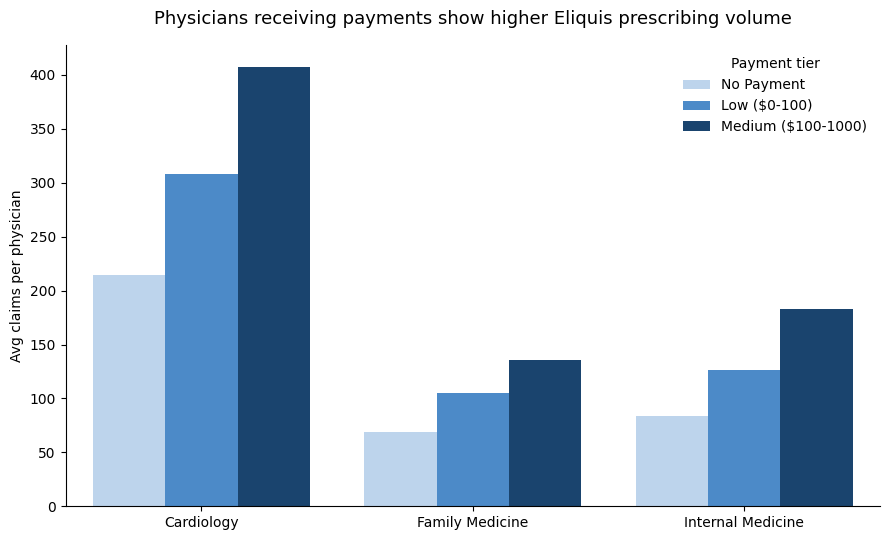

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out unreliable tiers/specialties before plotting
plot_data = summary_eliquis[
    (summary_eliquis['payment_tier'] != 'High ($1000+)') &
    (summary_eliquis['specialty_bucket'].isin(['Cardiology', 'Internal Medicine', 'Family Medicine']))
]

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=plot_data,
    x='specialty_bucket',
    y='avg_claims',
    hue='payment_tier',
    hue_order=['No Payment', 'Low ($0-100)', 'Medium ($100-1000)'],
    palette=['#B5D4F4', '#378ADD', '#0C447C'],
    ax=ax
)

ax.set_xlabel('')
ax.set_ylabel('Avg claims per physician')
ax.set_title('Physicians receiving payments show higher Eliquis prescribing volume', fontsize=13, pad=15)
ax.legend(title='Payment tier', frameon=False)
sns.despine()
plt.tight_layout()

plt.savefig('eliquis_claims_by_specialty.png', dpi=300, bbox_inches='tight')
plt.show()

In [71]:
state_summary_eliquis = con.sql("""
    SELECT
        state,
        paid_status,
        COUNT(*) AS num_prescribers,
        ROUND(AVG(total_claims), 1) AS avg_claims
    FROM doac_master_analysis
    WHERE brand = 'Eliquis'
      AND state IN (
        'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA',
        'KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
        'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN','TX','UT','VT',
        'VA','WA','WV','WI','WY','DC'
      )
    GROUP BY state, paid_status
""").df()

print(state_summary_eliquis.head())

  state paid_status  num_prescribers  avg_claims
0    OR        Paid              118       217.3
1    LA        Paid              625       212.7
2    MA        Paid              321       216.8
3    IA      Unpaid             2645        89.8
4    TX        Paid             2183       191.4


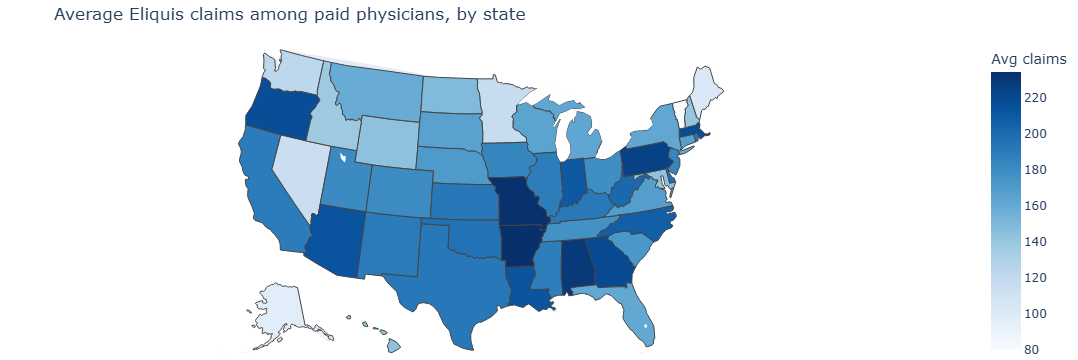

In [72]:
import plotly.express as px

# Filter to Paid physicians only, and keep the average claims per state
map_data = state_summary_eliquis[state_summary_eliquis['paid_status'] == 'Paid']

fig = px.choropleth(
    map_data,
    locations='state',
    locationmode='USA-states',
    color='avg_claims',
    scope='usa',
    color_continuous_scale='Blues',
    labels={'avg_claims': 'Avg claims'},
    title='Average Eliquis claims among paid physicians, by state'
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))

fig.write_image('eliquis_state_map.png', scale=2)
fig.show()

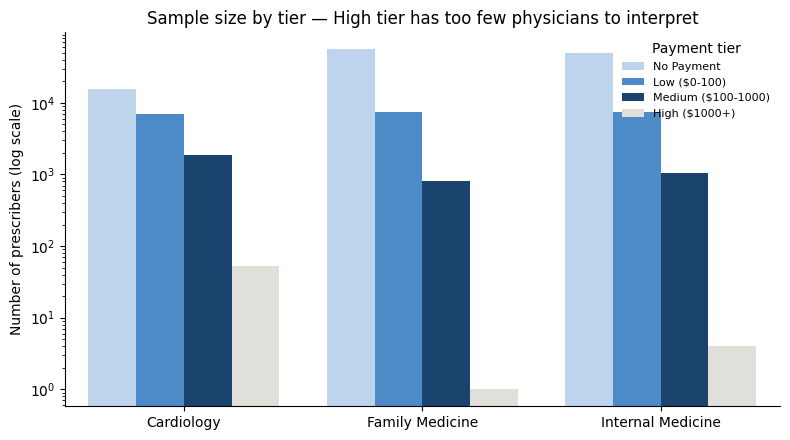

In [73]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=summary_eliquis[summary_eliquis['specialty_bucket'].isin(['Cardiology', 'Internal Medicine', 'Family Medicine'])],
    x='specialty_bucket',
    y='num_prescribers',
    hue='payment_tier',
    hue_order=['No Payment', 'Low ($0-100)', 'Medium ($100-1000)', 'High ($1000+)'],
    palette=['#B5D4F4', '#378ADD', '#0C447C', '#e1e0d9'],
    ax=ax
)
ax.set_yscale('log')
ax.set_ylabel('Number of prescribers (log scale)')
ax.set_xlabel('')
ax.set_title('Sample size by tier — High tier has too few physicians to interpret', fontsize=12)
ax.legend(title='Payment tier', frameon=False, fontsize=8)
sns.despine()
plt.tight_layout()

plt.savefig('sample_size_by_tier.png', dpi=300, bbox_inches='tight')
plt.show()

In [74]:
con.sql("""
    SELECT state, COUNT(*) AS row_count
    FROM doac_master_analysis
    WHERE state IN ('MO', 'AR')
    GROUP BY state
""").show()

┌─────────┬───────────┐
│  state  │ row_count │
│ varchar │   int64   │
├─────────┼───────────┤
│ AR      │      4139 │
│ MO      │      7993 │
└─────────┴───────────┘



In [75]:
con.sql("""
    SELECT state, COUNT(*) AS row_count
    FROM doac_master_analysis
    WHERE state NOT IN ('AA','AE','AP','GU','MP','PR','VI','XX','ZZ')
    GROUP BY state
    ORDER BY state ASC
""").show(max_rows=60)

┌─────────┬───────────┐
│  state  │ row_count │
│ varchar │   int64   │
├─────────┼───────────┤
│ AK      │       705 │
│ AL      │      5923 │
│ AR      │      4139 │
│ AZ      │      7418 │
│ CA      │     32116 │
│ CO      │      6248 │
│ CT      │      5080 │
│ DC      │       789 │
│ DE      │      1225 │
│ FL      │     29670 │
│ GA      │     10776 │
│ HI      │      1211 │
│ IA      │      4521 │
│ ID      │      2207 │
│ IL      │     14260 │
│ IN      │      8385 │
│ KS      │      3755 │
│ KY      │      6861 │
│ LA      │      5540 │
│ MA      │     10656 │
│ MD      │      6290 │
│ ME      │      2504 │
│ MI      │     14537 │
│ MN      │      8573 │
│ MO      │      7993 │
│ MS      │      3505 │
│ MT      │      1554 │
│ NC      │     14607 │
│ ND      │      1260 │
│ NE      │      2931 │
│ NH      │      2165 │
│ NJ      │     10092 │
│ NM      │      2209 │
│ NV      │      3082 │
│ NY      │     26755 │
│ OH      │     16226 │
│ OK      │      4424 │
│ OR      │     

In [76]:
con.sql("""
    SELECT
        top_payment_nature,
        COUNT(*) AS num_physicians,
        ROUND(AVG(total_claims), 1) AS avg_claims,
        ROUND(AVG(total_payment_amount), 0) AS avg_payment_amount,
        ROUND(AVG(total_drug_cost), 0) AS avg_drug_cost
    FROM doac_master_analysis
    WHERE brand = 'Eliquis' AND paid_status = 'Paid'
    GROUP BY top_payment_nature
    ORDER BY avg_claims DESC
""").show(max_rows=20)

┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────┬────────────┬────────────────────┬───────────────┐
│                                                                 top_payment_nature                                                                 │ num_physicians │ avg_claims │ avg_payment_amount │ avg_drug_cost │
│                                                                      varchar                                                                       │     int64      │   double   │       double       │    double     │
├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼────────────────┼────────────┼────────────────────┼───────────────┤
│ Compensation for services other than consulting, including serving as faculty or as a speaker at a venue other than a continui

In [77]:
con.sql("""
    SELECT
        specialty_bucket,
        top_payment_nature,
        COUNT(*) AS num_physicians,
        ROUND(AVG(total_claims), 1) AS avg_claims
    FROM doac_master_analysis
    WHERE brand = 'Eliquis'
      AND paid_status = 'Paid'
      AND specialty_bucket IN ('Cardiology', 'Internal Medicine', 'Family Medicine')
    GROUP BY specialty_bucket, top_payment_nature
    ORDER BY specialty_bucket, avg_claims DESC
""").show(max_rows=60)

┌───────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────┬────────────┐
│ specialty_bucket  │                                                                 top_payment_nature                                                                 │ num_physicians │ avg_claims │
│      varchar      │                                                                      varchar                                                                       │     int64      │   double   │
├───────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼────────────────┼────────────┤
│ Cardiology        │ Compensation for services other than consulting, including serving as faculty or as a speaker at a venue other than a continuing education program │             14 │      516

In [78]:
con.sql("""
    WITH nature_flags AS (
        SELECT DISTINCT npi, payment_nature
        FROM open_payments_doac_clean
        WHERE brand = 'Eliquis'
    )
    SELECT
        nf.payment_nature,
        COUNT(DISTINCT nf.npi) AS num_physicians,
        ROUND(AVG(m.total_claims), 1) AS avg_claims,
        ROUND(AVG(m.total_payment_amount), 0) AS avg_total_payment_all_natures
    FROM nature_flags nf
    JOIN doac_master_analysis m
      ON nf.npi = m.npi AND m.brand = 'Eliquis' AND m.paid_status = 'Paid'
    GROUP BY nf.payment_nature
    ORDER BY avg_claims DESC
""").show(max_rows=20)

┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────┬────────────┬───────────────────────────────┐
│                                                                   payment_nature                                                                   │ num_physicians │ avg_claims │ avg_total_payment_all_natures │
│                                                                      varchar                                                                       │     int64      │   double   │            double             │
├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼────────────────┼────────────┼───────────────────────────────┤
│ Compensation for services other than consulting, including serving as faculty or as a speaker at a venue other than a continuing education program

In [79]:
con.sql("""
    SELECT
        Brnd_Name,
        COUNT(*) AS total_rows,
        COUNT(Tot_Benes) AS rows_with_benes,
        COUNT(*) - COUNT(Tot_Benes) AS rows_missing_benes
    FROM partd_prescriber_raw
    WHERE Brnd_Name ILIKE '%eliquis%' OR Brnd_Name ILIKE '%xarelto%'
    GROUP BY Brnd_Name
""").show()

┌───────────┬────────────┬─────────────────┬────────────────────┐
│ Brnd_Name │ total_rows │ rows_with_benes │ rows_missing_benes │
│  varchar  │   int64    │      int64      │       int64        │
├───────────┼────────────┼─────────────────┼────────────────────┤
│ Xarelto   │     134291 │           36918 │              97373 │
│ Eliquis   │     264286 │          145620 │             118666 │
└───────────┴────────────┴─────────────────┴────────────────────┘



In [80]:
con.sql("""
    CREATE OR REPLACE TABLE partd_benes AS
    SELECT
        CAST(Prscrbr_NPI AS VARCHAR) AS npi,
        Brnd_Name AS brand,
        Tot_Benes AS total_benes
    FROM partd_prescriber_raw
    WHERE Brnd_Name ILIKE '%eliquis%' OR Brnd_Name ILIKE '%xarelto%'
""")

con.sql("""
    CREATE OR REPLACE TABLE doac_master_with_benes AS
    SELECT
        m.*,
        b.total_benes,
        ROUND(m.total_claims / NULLIF(b.total_benes, 0), 1) AS claims_per_beneficiary
    FROM doac_master_analysis m
    LEFT JOIN partd_benes b
      ON m.npi = b.npi AND m.brand = b.brand
""")

print(con.sql("SELECT COUNT(*), COUNT(total_benes) FROM doac_master_with_benes").df())

   count_star()  count(total_benes)
0        398577              182538


In [81]:
con.sql("""
    SELECT
        specialty_bucket,
        payment_tier,
        COUNT(*) AS num_physicians,
        ROUND(AVG(total_benes), 1) AS avg_beneficiaries,
        ROUND(AVG(claims_per_beneficiary), 2) AS avg_claims_per_beneficiary
    FROM doac_master_with_benes
    WHERE brand = 'Eliquis'
      AND specialty_bucket IN ('Cardiology', 'Internal Medicine', 'Family Medicine')
    GROUP BY specialty_bucket, payment_tier
    ORDER BY specialty_bucket,
        CASE payment_tier
            WHEN 'No Payment' THEN 0
            WHEN 'Low ($0-100)' THEN 1
            WHEN 'Medium ($100-1000)' THEN 2
            WHEN 'High ($1000+)' THEN 3
        END
""").show(max_rows=20)

┌───────────────────┬────────────────────┬────────────────┬───────────────────┬────────────────────────────┐
│ specialty_bucket  │    payment_tier    │ num_physicians │ avg_beneficiaries │ avg_claims_per_beneficiary │
│      varchar      │      varchar       │     int64      │      double       │           double           │
├───────────────────┼────────────────────┼────────────────┼───────────────────┼────────────────────────────┤
│ Cardiology        │ No Payment         │          15842 │              64.1 │                       3.64 │
│ Cardiology        │ Low ($0-100)       │           7038 │              81.1 │                       3.78 │
│ Cardiology        │ Medium ($100-1000) │           1857 │             100.9 │                       3.93 │
│ Cardiology        │ High ($1000+)      │             52 │             151.7 │                       3.86 │
│ Family Medicine   │ No Payment         │          55951 │              22.8 │                       4.39 │
│ Family Medicine  

In [82]:
con.sql("""
    SELECT
        specialty_bucket,
        payment_tier,
        COUNT(*) AS num_physicians_total,
        COUNT(total_benes) AS num_with_benes_disclosed,
        ROUND(100.0 * COUNT(total_benes) / COUNT(*), 1) AS pct_disclosed,
        ROUND(AVG(total_benes), 1) AS avg_beneficiaries,
        ROUND(AVG(claims_per_beneficiary), 2) AS avg_claims_per_beneficiary
    FROM doac_master_with_benes
    WHERE brand = 'Eliquis'
      AND specialty_bucket IN ('Cardiology', 'Internal Medicine', 'Family Medicine')
    GROUP BY specialty_bucket, payment_tier
    ORDER BY specialty_bucket,
        CASE payment_tier
            WHEN 'No Payment' THEN 0
            WHEN 'Low ($0-100)' THEN 1
            WHEN 'Medium ($100-1000)' THEN 2
            WHEN 'High ($1000+)' THEN 3
        END
""").show(max_rows=20)

┌───────────────────┬────────────────────┬──────────────────────┬──────────────────────────┬───────────────┬───────────────────┬────────────────────────────┐
│ specialty_bucket  │    payment_tier    │ num_physicians_total │ num_with_benes_disclosed │ pct_disclosed │ avg_beneficiaries │ avg_claims_per_beneficiary │
│      varchar      │      varchar       │        int64         │          int64           │    double     │      double       │           double           │
├───────────────────┼────────────────────┼──────────────────────┼──────────────────────────┼───────────────┼───────────────────┼────────────────────────────┤
│ Cardiology        │ No Payment         │                15842 │                    13693 │          86.4 │              64.1 │                       3.64 │
│ Cardiology        │ Low ($0-100)       │                 7038 │                     6790 │          96.5 │              81.1 │                       3.78 │
│ Cardiology        │ Medium ($100-1000) │          